In [1]:
import torch
import torch.nn as nn
import numpy as np
import h5py
import matplotlib.pyplot as plt

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [4]:
#these are same parameters as that of fipy solver
rho = 780.0
cp = 2000.0
k = 0.2
L = 2e5

Tm = 50.0
dT = 2.0

In [5]:
#im loading one dataset
file = r"C:\Users\raksh\Downloads\pcm_dataset_2D\pcm2D_case_0040.h5"

with h5py.File(file,"r") as f:
    
    x = f["case/x"][:]
    y = f["case/y"][:]
    times = f["case/times"][:]
    
    T = f["case/T"][:]      # (nt,ny,nx)

In [6]:
print(T.shape)

(73, 40, 80)


In [7]:
#now convert data into training points
X, Y, TT = np.meshgrid(x,y,times,indexing="ij")

coords = np.stack([
    X.flatten(),
    Y.flatten(),
    TT.flatten()
],axis=1)

targets = T.transpose(2,1,0).flatten()

In [8]:
coords = torch.from_numpy(coords).float().to(device)
targets = torch.from_numpy(targets).float().unsqueeze(1).to(device)

##this ensures data is a pytorch tensor(not a nuumpy array),data does not carry old gradient history and its float32. Why colne?cuz If you modify tensors that share memory, PyTorch may accidentally modify the original dataset.

In [9]:
print(coords.shape)

torch.Size([233600, 3])


In [10]:
#defining PINN model
class PINN(nn.Module):
    
    def __init__(self):
        super(PINN, self).__init__()

        self.network = nn.Sequential(
            nn.Linear(3, 64),
            nn.Tanh(),
            
            nn.Linear(64, 64),
            nn.Tanh(),
            
            nn.Linear(64, 64),
            nn.Tanh(),
            
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.network(x)

In [11]:
model = PINN().to(device) #creating model

In [12]:
#liquid fraction functions
def df_dT(T):

    Ts = Tm - dT
    Tl = Tm + dT

    mask = (T > Ts) & (T < Tl)

    df = torch.zeros_like(T)

    xi = (T - Ts)/(2*dT)

    df[mask] = (6*xi[mask] - 6*xi[mask]**2)/(2*dT)

    return df

In [13]:
#PHYSICS RESIDUAL,this is the core of PINNs
def pde_residual(model,xyt):

    xyt.requires_grad_(True)

    T_pred = model(xyt)

    grads = torch.autograd.grad(
        T_pred,
        xyt,
        torch.ones_like(T_pred),
        create_graph=True
    )[0]

    Tx = grads[:,0:1]
    Ty = grads[:,1:2]
    Tt = grads[:,2:3]

    Txx = torch.autograd.grad(
        Tx,xyt,torch.ones_like(Tx),create_graph=True
    )[0][:,0:1]

    Tyy = torch.autograd.grad(
        Ty,xyt,torch.ones_like(Ty),create_graph=True
    )[0][:,1:2]

    ceff = cp + L*df_dT(T_pred)

    residual = rho*ceff*Tt - k*(Txx + Tyy)

    return residual

In [14]:
#loss function
def loss_function(model,coords,targets):

    pred = model(coords)

    data_loss = torch.mean((pred-targets)**2)

    res = pde_residual(model,coords)

    physics_loss = torch.mean(res**2)

    loss = data_loss + physics_loss

    return loss

In [15]:
#optimizer
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

In [16]:
#training loop
epochs = 2000
batch_size = 4096

N = coords.shape[0]

for epoch in range(epochs):

    idx = torch.randperm(N)[:batch_size]

    batch_coords = coords[idx]
    batch_targets = targets[idx]

    optimizer.zero_grad()

    loss = loss_function(model, batch_coords, batch_targets)

    loss.backward()

    optimizer.step()

    if epoch % 100 == 0:
        print(epoch, loss.item())

0 94052648.0
100 17405.3515625
200 17173.908203125
300 17181.1796875
400 17170.037109375
500 17245.5078125
600 16968.240234375
700 17288.564453125
800 17089.966796875
900 17088.765625
1000 17295.77734375
1100 17183.6171875
1200 16950.3359375
1300 17072.361328125
1400 16939.736328125
1500 16963.66015625
1600 17093.9140625
1700 16918.263671875
1800 16905.65625
1900 16831.7265625


In [17]:
with torch.no_grad():

    T_pred = model(coords).cpu().numpy()

In [18]:
T_pred = T_pred.reshape(len(x),len(y),len(times))

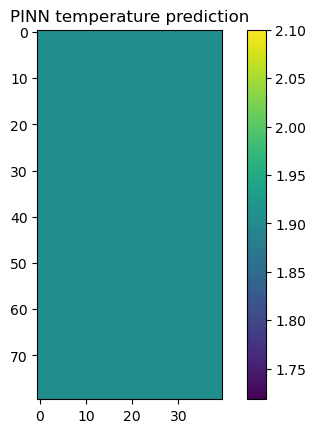

In [19]:
plt.imshow(T_pred[:,:, -1])
plt.colorbar()
plt.title("PINN temperature prediction")
plt.show()